# A Tutorial for Downloading, Processing, and Validating Level 4 Surface Monitor Station Data Against Ground-Based AirNow Sensors
This tutorial demonstrates a comprehensive workflow for accessing NASA's MAIA (Multi-Angle Imager for Aerosols) Level 4 surface monitor station data using the NASA Harmony tool. The tutorial guides users through:
- Data Download & Processing: Programmatically downloading MAIA Level 4 PM₂.₅ data and converting to Cloud Optimized GeoTIFFs (COGs)
- Spatial Alignment: Extracting MAIA pixels that correspond to AirNow ground-based sensor locations
- Comparative Validation: Performing statistical comparisons between satellite-derived and ground-measured PM₂.₅ concentrations
- Visualization: Creating publication-quality maps and time-series plots showing correlations between datasets


The example focuses on New York City with a 50 km × 50 km study area, comparing noon-hour PM₂.₅ observations

For questions or concerns, please contact:

<b> Mission Point of Contact/Tutorial Author </b> 
- Sarah Scott: sarah.r.scott@nasa.gov

<b> ASDC Project Scientist </b>
- Hazem Mahmoud: hazem.mahmoud@nasa.gov

## Installations and Imports

In [52]:
!pip install harmony-py contextily pyrsig earthaccess

In [1]:
#import necessary packages
from pathlib import Path
from harmony import Client, Collection, Environment, Request
import getpass
import earthaccess
import datetime as dt
from cmr import VariableQuery
import math
import folium
import os
import pandas as pd
import pyrsig
import re
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import contextily as ctx
from rasterio.warp import calculate_default_transform,reproject, Resampling, transform_bounds
from matplotlib.ticker import FuncFormatter
from geopy.geocoders import Nominatim
import time
from rasterio.warp import transform as crs_transform
from scipy import stats
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn import metrics
from datetime import datetime
import matplotlib.dates as mdates
import geopandas as gpd
geolocator = Nominatim(user_agent="airnow_station_lookup")

shp_path = "nybb.shp"
shp_dir = Path('/home/jovyan/net2cog/shapefile')
if shp_dir.is_dir():
    roads = gpd.read_file(os.path.join(shp_dir, shp_path))
    if roads.crs != "EPSG:4326": roads = roads.to_crs("EPSG:4326")

    print('Shapefile downloaded')
else: 
    print('No shapefile found')
    shp_path= None

Shapefile downloaded


In [2]:
#helper functions
def single_var_harmony_download(concept_id, short_name, version,yyyy_ini, mm_ini, dd_ini, yyyy_fin, mm_fin, dd_fin, output_dir, variable_select=True):
    earthaccess.login()
    concept_id=concept_id
    granules = earthaccess.search_data(concept_id=concept_id,temporal=(f"{yyyy_ini}-{mm_ini}-{dd_ini}", f"{yyyy_fin}-{mm_fin}-{dd_fin}"))
    print(f"Found {len(granules)} granules")
    granule_ids = [g["meta"]["concept-id"] for g in granules]
    if variable_select:
        """List variable names for an Earthdata collection via CMR."""
        results = earthaccess.search_datasets(short_name=short_name,version=version,)
        # Identify the collection. Change short_name/version for other datasets.
        collection = results[0]
        
        # UMM-C lists associated UMM-Var concept IDs under meta.associations.
        var_ids = collection["meta"]["associations"]["variables"]
        
        # Look up each UMM-Var record by concept ID.
        variables = VariableQuery().concept_id(var_ids).get_all()
        
        # Using the UMM-Var "name" (there's also a "long_name" and other attributes).
        names = sorted(v["name"] for v in variables)
        print(f"{len(names)} variables in {collection['umm']['ShortName']}:")
        for n in names:
            print(f"  {n}")
        
        variable = input('enter variable of interest (NOTE PAY ATTENTION TO FORWARD AND BACKWARD SLASHES AND INCLUDE)')
    else: variable = '/PM_2.5/PM_2.5_Total_Mean'

    #MAIA Level 4 Particulate Matter Product Version 001 C2574931653-LARC_ASDC
    collection = Collection(id = concept_id)
    request = Request(
        collection=collection,
        granule_id= [g["meta"]["concept-id"] for g in granules],
        temporal = {
            'start': dt.datetime(yyyy_ini, mm_ini, dd_ini, 23, 59, 59),
            'stop': dt.datetime(yyyy_fin, mm_fin, dd_fin, 23, 59, 59)
                    },
        # variables=['/PM_2.5/PM_2.5_Total_Mean'],
        variables = [variable],
        format='image/tiff',
    )                      
    # Validate the request before submitting
    print(f'Request is valid: {request.is_valid()}')
    #process job and save cloud optimized geotiffs
    job_id = harmony_client.submit(request)
    print(f"jobID = {job_id}")
    harmony_client.wait_for_processing(job_id, show_progress=True)
    results = harmony_client.download_all(job_id, directory=output_dir)
    all_results_stored = [f.result() for f in results]
    print(f"Number of result files: {len(all_results_stored)}")



def get_city(lat, lon):
    try:
        location = geolocator.reverse((lat, lon),exactly_one=True,language="en")
        if location is None:
            return None

        address = location.raw["address"]
        # Prefer the most specific populated place
        return (
            address.get("neighbourhood")
            or address.get("suburb")
            or address.get("hamlet")
            or address.get("borough")
            or address.get("city_district")
            or address.get("quarter")
            or address.get("city")
            or address.get("town")
            or address.get("village")
            or address.get("municipality")
            or address.get("county")
        )

    except Exception as e:
        print(f"Failed for {lat}, {lon}: {e}")
        return None

def get_rectangle_polygon(lat, lon, width_km, height_km):
    """
    Compute a rectangular polygon (4 corner coordinates) centered at (lat, lon).

    Parameters:
        lat (float): Center latitude in degrees
        lon (float): Center longitude in degrees
        width_km (float): Total width (East-West) in km
        height_km (float): Total height (North-South) in km
    
    Returns:
        list: List of 4 (lat, lon) tuples representing the rectangle corners
    """
    earth_radius_km = 6371.0 
    
    # Compute half-width and half-height in degrees
    delta_lat = (height_km / 2) / 111.32  # 1 degree latitude ≈ 111.32 km
    delta_lon = (width_km / 2) / (111.32 * math.cos(math.radians(lat)))  # Adjust for longitude

    top_left = (lat + delta_lat, lon - delta_lon)
    top_right = (lat + delta_lat, lon + delta_lon)
    bottom_right = (lat - delta_lat, lon + delta_lon)
    bottom_left = (lat - delta_lat, lon - delta_lon)

    return [top_left, top_right, bottom_right, bottom_left]

def check_site(metric, queries):
    metric_list = []
    for q in queries:
        if metric in q:
            metric_list.append(metric)
    return metric_list

def take_airnow_inputs(date_start,date_end,start_date,end_date, polygon_corners,save=False):
    rsigapi = pyrsig.RsigApi(bdate=date_start,edate=date_end,bbox=(
            polygon_corners[3][1],
            polygon_corners[3][0],
            polygon_corners[1][1],
            polygon_corners[1][0],),)

    descdf = rsigapi.descriptions()
    queries = (descdf.query('name.str.contains("airnow")').reset_index(drop=True))
    metric = "airnow.pm25"

    if metric not in queries["name"].values:
        raise ValueError(
            f"{metric} is not available for the requested time period."
        )

    airnow_df = rsigapi.to_dataframe(metric,parse_dates=True,unit_keys=False,verbose=9,)

    if save: airnow_df.to_csv( f"AIRNOW_pm25_{start_date}_{end_date}.csv", index=False,)
    return airnow_df

def df_setup_noon(df):
    sites = (df[["STATION", "LATITUDE", "LONGITUDE"]].drop_duplicates().copy())
    cities = []
    for _, row in sites.iterrows():
        city = get_city(row["LATITUDE"], row["LONGITUDE"])
        cities.append(city)
        print( f"{row['STATION']} -> {city}")
        time.sleep(1)
    
    sites["CITY"] = cities
    station_city_lookup = (sites[["STATION", "CITY"]].drop_duplicates())
    df =df.merge(station_city_lookup,on="STATION",how="left")
    
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df["date"] = df["Timestamp"].dt.date
    df["hour"] = df["Timestamp"].dt.hour
    df_noon = df[df["hour"] == 12].copy()
    df_daily = (df_noon.groupby(["STATION", "CITY", "LATITUDE", "LONGITUDE", "date"],as_index=False).agg(pm25_noon=("pm25", "mean"))) #noon measurements only
    
    return df_daily

In [3]:
## Log in with Earthdata credentials
print("Please provide your Earthdata Login credentials to allow data access")
print("Your credentials will only be passed to Earthdata and will not be exposed in the notebook")
username = input("Username:")
harmony_client = Client(env=Environment.PROD, auth=(username, getpass.getpass()))

Please provide your Earthdata Login credentials to allow data access
Your credentials will only be passed to Earthdata and will not be exposed in the notebook


Username: sarah_scott_nasa
 ········


Define 50km$^{2}$ area of interest.

In [4]:
# pgonlat, pgonlon = 42.3601, -71.058940 #boston
#new york city: 40.7128, -74.0060
pgonlat, pgonlon = 40.7128, -74.0060 #new york
polygon_corners = get_rectangle_polygon(pgonlat, pgonlon, width_km=50, height_km=50)

#visualize region
polygon_corners.append(polygon_corners[0])
m = folium.Map(location=(pgonlat, pgonlon), zoom_start=10)

# Add polygon to the map
folium.Polygon(locations=polygon_corners,color="blue",fill=True,fill_color="cyan",fill_opacity=0.25).add_to(m)

folium.CircleMarker(location = [polygon_corners[0][0], polygon_corners[0][1]], radius = 3, color = 'black', popup = '1', fill= False).add_to(m)
folium.CircleMarker(location = [polygon_corners[1][0], polygon_corners[1][1]], radius = 3, color = 'black', popup ='2', fill= False).add_to(m)
folium.CircleMarker(location = [polygon_corners[2][0], polygon_corners[2][1]], radius = 3, color = 'black', popup = '3', fill= False).add_to(m)
folium.CircleMarker(location = [polygon_corners[3][0], polygon_corners[3][1]], radius = 3, color = 'black', popup='4', fill= False).add_to(m)
folium.Marker(location = (pgonlat, pgonlon), color = 'black', fill = False, popup='Pandora').add_to(m)
# m #show map

## Setup for location analysis

In [5]:
#Define and create output directory for COGs
output_dir = Path("./net2cog-L4-output")
output_dir.mkdir(exist_ok=True)

In [6]:
# looking at a week
print('enter period of interest, start and end dates, in the form YYYYMMDD')
datestamp_ini = input('enter start date of interest ')
datestamp_fin = input('enter end date of interest ')

start_date = int(datestamp_ini)
end_date = int(datestamp_fin)

yyyy_ini = start_date//10000
mm_ini = (start_date//100 - yyyy_ini*100)
dd_ini = (start_date - yyyy_ini*10000 - mm_ini*100)

yyyy_fin = end_date//10000
mm_fin = (end_date//100 - yyyy_fin*100)
dd_fin = (end_date - yyyy_fin*10000 - mm_fin*100)
print(yyyy_ini, mm_ini, dd_ini, yyyy_fin, mm_fin, dd_fin)

date_start = str('%4.4i-%2.2i-%2.2i 00:00:00' %(yyyy_ini, mm_ini, dd_ini))
date_end = str('%4.4i-%2.2i-%2.2i 23:59:59' %(yyyy_fin, mm_fin, dd_fin))

enter period of interest, start and end dates, in the form YYYYMMDD


enter start date of interest  20180825
enter end date of interest  20180903


2018 8 25 2018 9 3


In [7]:
#access airnow station data, for this example we want to compare pm25
x = take_airnow_inputs(date_start, date_end, start_date, end_date, polygon_corners, save = True)

https://ofmpub.epa.gov/rsig/rsigserver?SERVICE=wcs&VERSION=1.0.0&REQUEST=GetCoverage&FORMAT=ascii&TIME=2018-08-25T00:00:00Z/2018-09-03T23:59:59Z&BBOX=-74.3022812141979,40.488222206252246,-73.7097187858021,40.93737779374776&COVERAGE=airnow.pm25&COMPRESS=1
Using cached: ./airnow.pm25_2018-08-25T000000Z_2018-09-03T235959Z.csv.gz


In [8]:
x_daily = df_setup_noon(x)

8779.0 -> Koreatown
8793.0 -> Hilltop
8811.0 -> Elizabeth
8812.0 -> Rahway
8856.0 -> High Bridge
8874.0 -> Sunset Park
8880.0 -> Fort George
8883.0 -> East Village
8884.0 -> Two Bridges
8885.0 -> Hamilton Heights
8895.0 -> Queens
8896.0 -> Pomonok
8897.0 -> Queens
8899.0 -> Port Richmond


In [9]:
## Harmony setup and Cloud Optimized GeoTIFF (COG) download
single_var_harmony_download("C2574931653-LARC_ASDC", "MAIA_L4_GFPM", "VSIM001", yyyy_ini, mm_ini, dd_ini, yyyy_fin, mm_fin, dd_fin, output_dir)

/srv/conda/envs/notebook/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


Found 11 granules
21 variables in MAIA_L4_GFPM:
  /Geometric_Parameters/Latitude
  /Geometric_Parameters/Longitude
  /PM_10/PM_10_Total_Mean
  /PM_2.5/PM_2.5_Total_Mean
  /X_Dim
  Albers_Equal_Area
  PM_10/PM_10_Total_Uncertainty
  PM_2.5/PM_2.5_Dust_Mean
  PM_2.5/PM_2.5_Dust_Uncertainty
  PM_2.5/PM_2.5_EC_Mean
  PM_2.5/PM_2.5_EC_Uncertainty
  PM_2.5/PM_2.5_Nitrate_Mean
  PM_2.5/PM_2.5_Nitrate_Uncertainty
  PM_2.5/PM_2.5_OC_Mean
  PM_2.5/PM_2.5_OC_Uncertainty
  PM_2.5/PM_2.5_Sulfate_Mean
  PM_2.5/PM_2.5_Sulfate_Uncertainty
  PM_2.5/PM_2.5_Total_Mean
  PM_2.5/PM_2.5_Total_Uncertainty
  X_Dim
  Y_Dim


enter variable of interest (NOTE PAY ATTENTION TO FORWARD AND BACKWARD SLASHES AND INCLUDE) /PM_2.5/PM_2.5_Total_Mean


Request is valid: True


 [ Processing:   0% ] |                                                   | [/]

jobID = f53e0525-2e66-4d3d-b18a-7f561f2d502f


 [ Processing: 100% ] |###################################################| [|]


net2cog-L4-output/242432107_MAIA_L4_GFPM_20180826T000000Z_FB_NOM_R01_USA-Boston_F01_VSIM01p01p01p01_PM_2.5_PM_2.5_Total_Mean_reformatted.tif
net2cog-L4-output/242432106_MAIA_L4_GFPM_20180825T000000Z_FB_NOM_R01_USA-Boston_F01_VSIM01p01p01p01_PM_2.5_PM_2.5_Total_Mean_reformatted.tif
net2cog-L4-output/242432108_MAIA_L4_GFPM_20180827T000000Z_FB_NOM_R01_USA-Boston_F01_VSIM01p01p01p01_PM_2.5_PM_2.5_Total_Mean_reformatted.tif
net2cog-L4-output/242432109_MAIA_L4_GFPM_20180828T000000Z_FB_NOM_R01_USA-Boston_F01_VSIM01p01p01p01_PM_2.5_PM_2.5_Total_Mean_reformatted.tif
net2cog-L4-output/242432111_MAIA_L4_GFPM_20180830T000000Z_FB_NOM_R01_USA-Boston_F01_VSIM01p01p01p01_PM_2.5_PM_2.5_Total_Mean_reformatted.tif
net2cog-L4-output/242432110_MAIA_L4_GFPM_20180829T000000Z_FB_NOM_R01_USA-Boston_F01_VSIM01p01p01p01_PM_2.5_PM_2.5_Total_Mean_reformatted.tif
net2cog-L4-output/242432112_MAIA_L4_GFPM_20180831T000000Z_FB_NOM_R01_USA-Boston_F01_VSIM01p01p01p01_PM_2.5_PM_2.5_Total_Mean_reformatted.tif
net2cog-L4-ou

### Figure setup and time series analysis

Download and extract shapefile for New York boundaries here (select Borough Boundaries (Clipped to Shoreline)): https://www.nyc.gov/content/planning/pages/resources/datasets/borough-boundaries

In [10]:
#geolocate MAIA pixels based on airnow station location--NOTE MAIA GRANULES ARE IN ALBERS EQUAL AREA PROJECTION AND MOST BE TRANSFORMED
x_daily = x_daily.copy()
x_daily["date"] = pd.to_datetime(x_daily["date"]).dt.date
maia_lookup = {}
for fname in os.listdir(output_dir):
    if not fname.endswith(".tif"): continue
    match = re.search(r"(\d{8})T\d{6}Z", fname)
    if match:
        file_date = pd.to_datetime(match.group(1),format="%Y%m%d").date()
        maia_lookup[file_date] = os.path.join(output_dir,fname)

maia_values = []
for _, row in x_daily.iterrows():
    date = row["date"]
    lon = row["LONGITUDE"]
    lat = row["LATITUDE"]
    tif = maia_lookup.get(date)

    if tif is None:
        maia_values.append(np.nan)
        continue

    try:
        with rasterio.open(tif) as src:
            x_proj, y_proj = crs_transform("EPSG:4326",src.crs,[lon],[lat])
            r, c = src.index(x_proj[0], y_proj[0] )

            if ( r < 0 or r >= src.height or c < 0 or c >= src.width):
                maia_values.append(np.nan)
                continue

            value = src.read(1, window=((r, r + 1), (c, c + 1)))[0, 0]

            if (src.nodata is not None and np.isclose(value, src.nodata)):
                value = np.nan

            maia_values.append(float(value))

    except Exception as e:
        print(f"Failed {row['CITY']} {date}: {e}")
        maia_values.append(np.nan)

x_daily["maia_pm25"] = maia_values
print(x_daily.head())

   STATION       CITY  LATITUDE  LONGITUDE        date  pm25_noon  maia_pm25
0     8779  Koreatown  40.85355   -73.9661  2018-08-25        8.9   9.777498
1     8779  Koreatown  40.85355   -73.9661  2018-08-26       10.0  13.152446
2     8779  Koreatown  40.85355   -73.9661  2018-08-27       21.1  17.704298
3     8779  Koreatown  40.85355   -73.9661  2018-08-28       36.0  20.786528
4     8779  Koreatown  40.85355   -73.9661  2018-08-29       26.0  17.987612


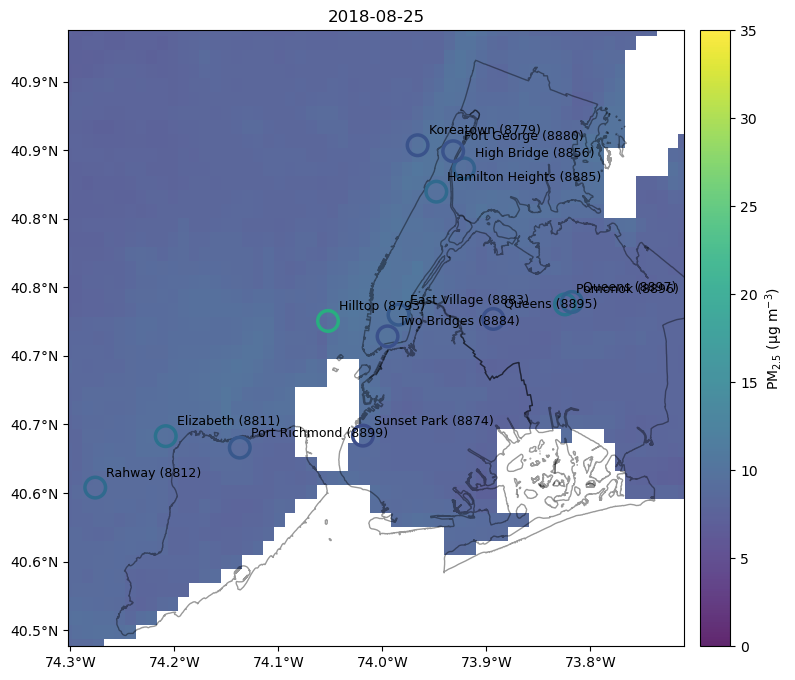

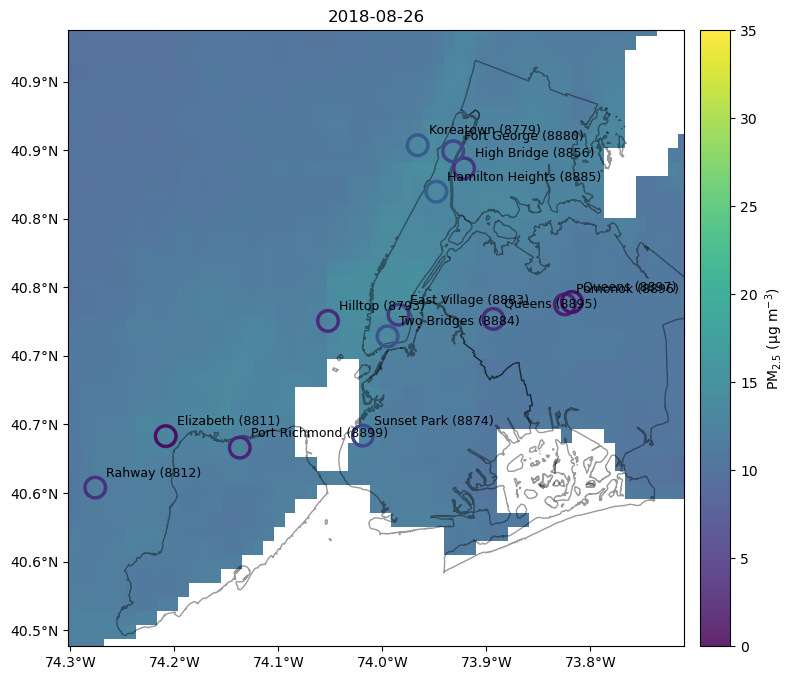

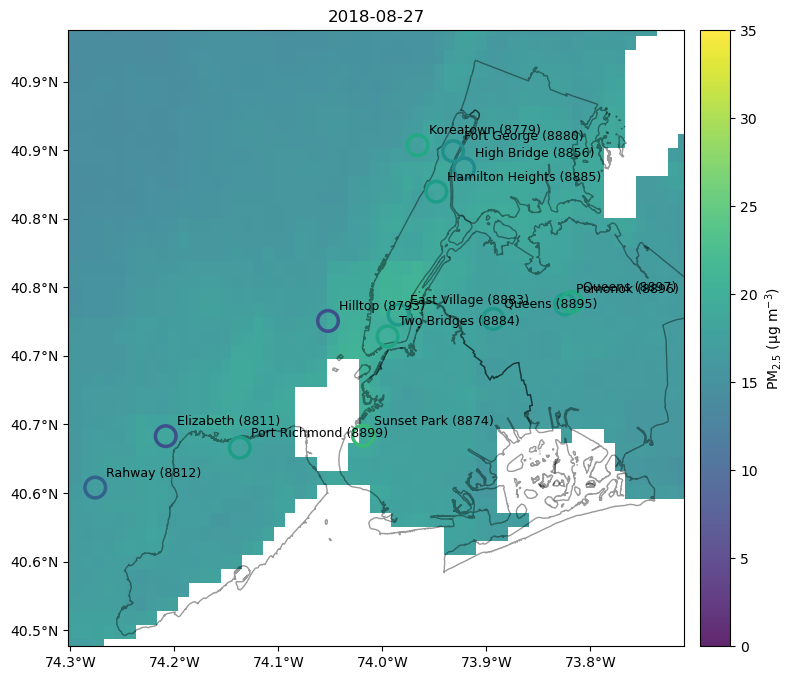

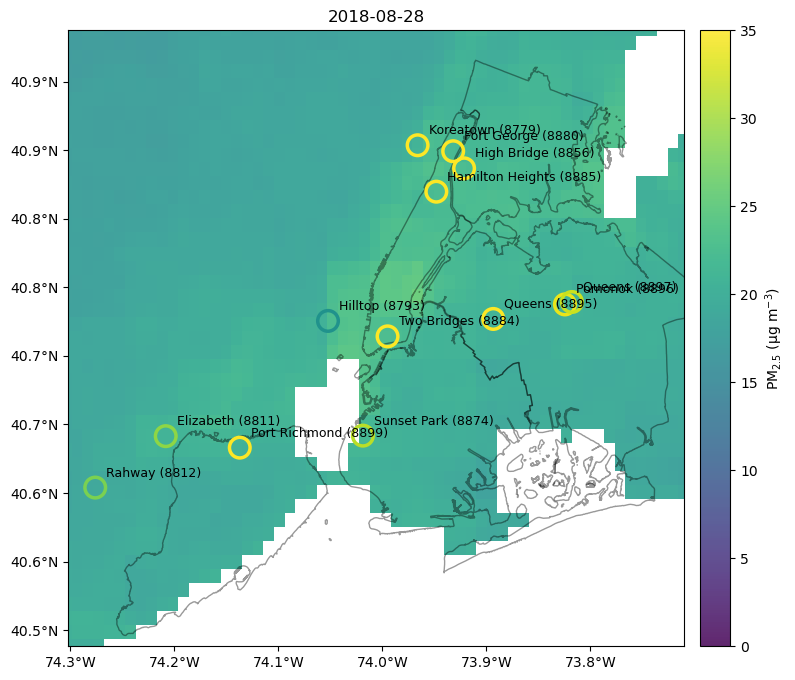

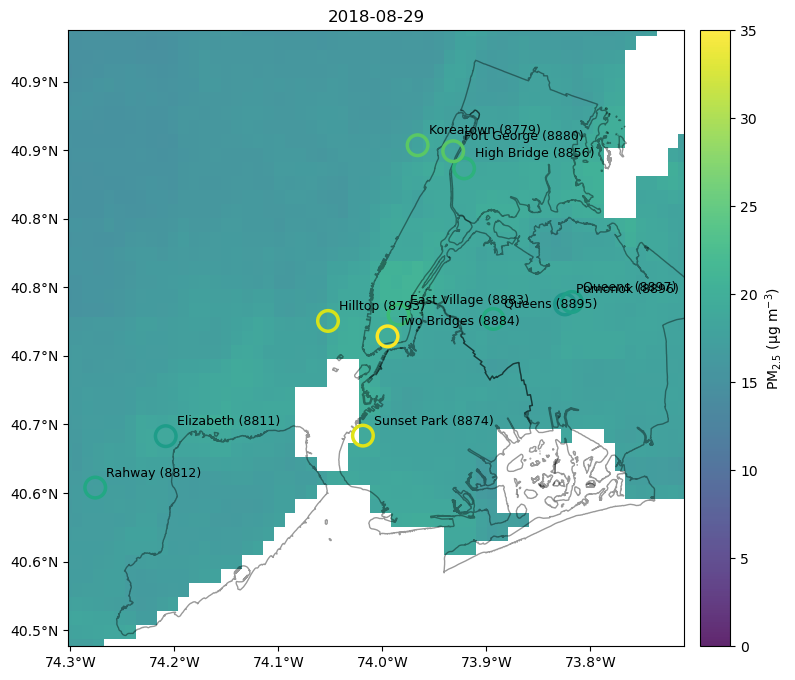

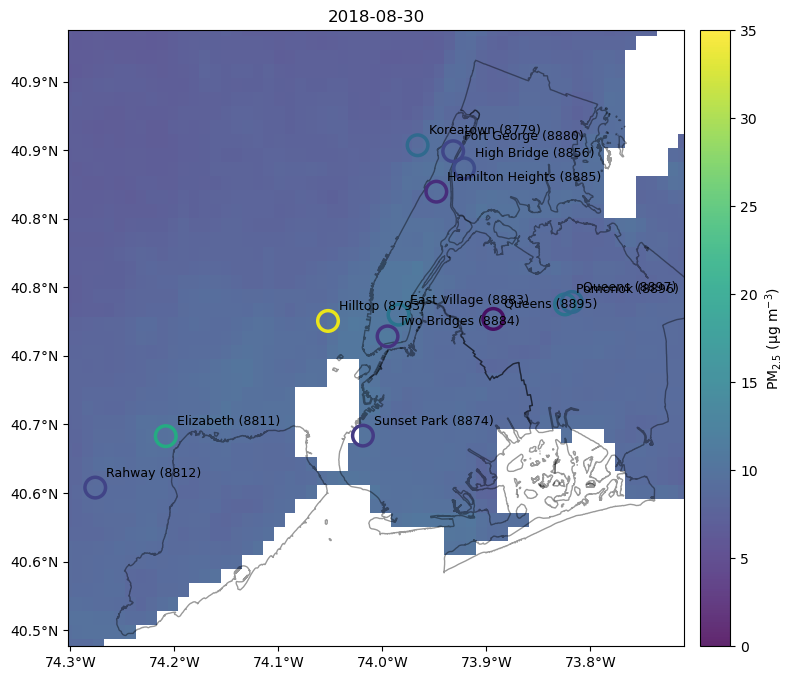

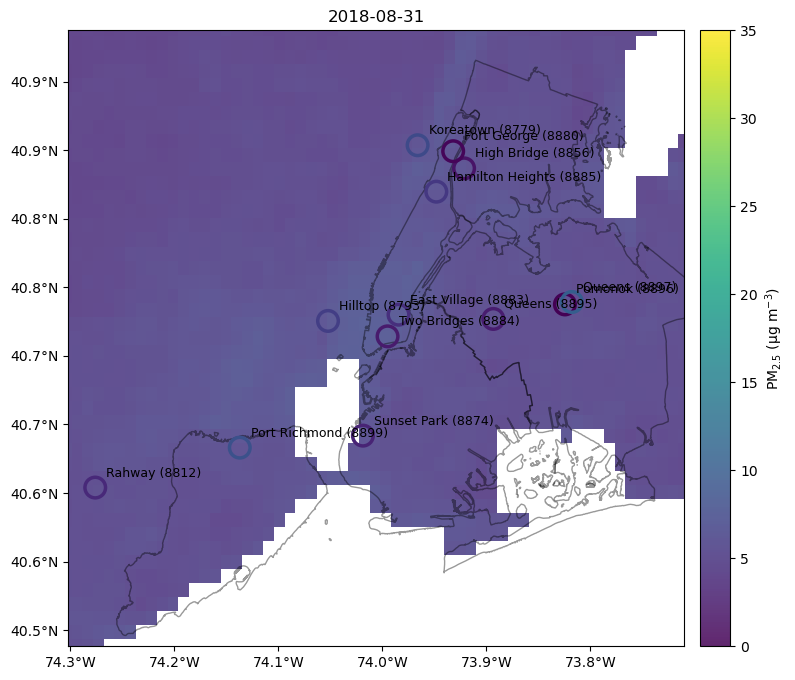

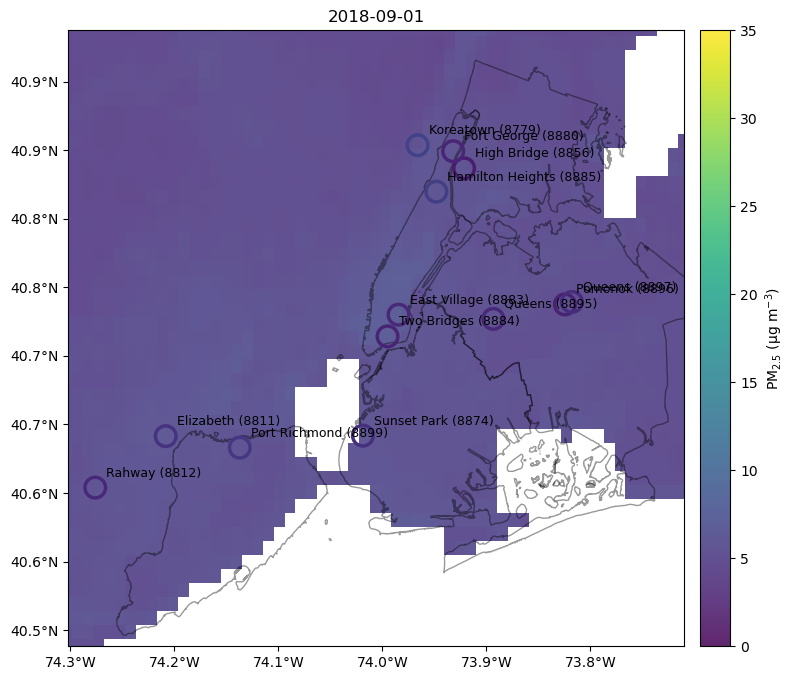

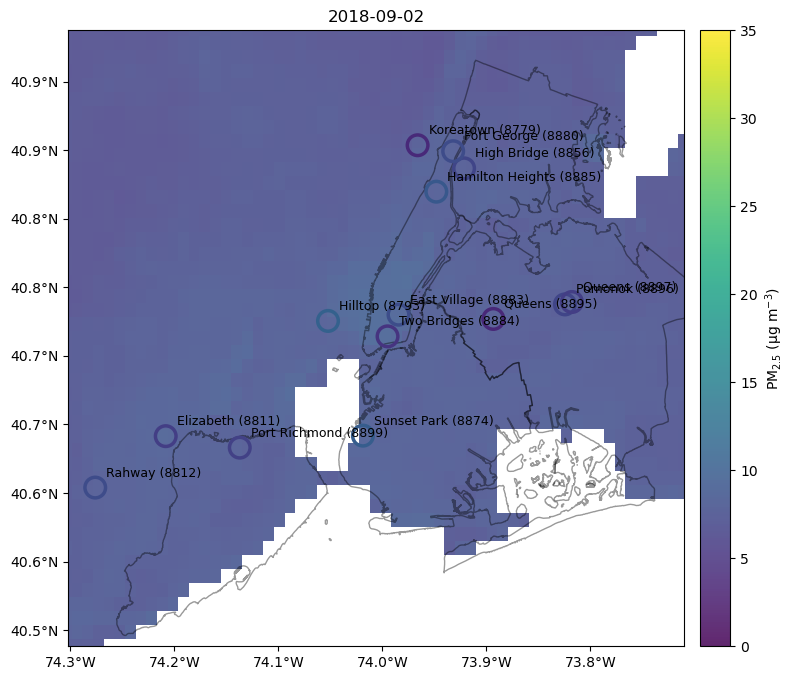

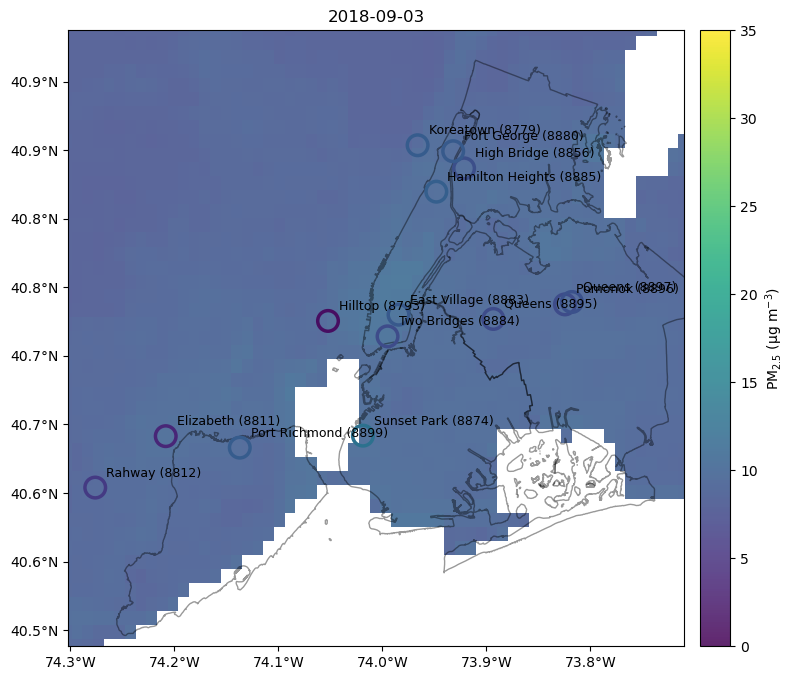

In [11]:
#daily image with AirNow stations
poly_lons = [p[1] for p in polygon_corners]
poly_lats = [p[0] for p in polygon_corners]
xmin = min(poly_lons)
xmax = max(poly_lons)
ymin = min(poly_lats)
ymax = max(poly_lats)
for plot_date in sorted(maia_lookup.keys()):
    maia_file = maia_lookup[plot_date]
    with rasterio.open(maia_file) as src:
        img = src.read(1).astype(np.float32)
        min_lon, min_lat, max_lon, max_lat = transform_bounds(src.crs,"EPSG:4326",*src.bounds)
        
        if src.nodata is not None:
            img[img == src.nodata] = np.nan

        transform, width, height = calculate_default_transform(src.crs,"EPSG:4326",src.width,src.height,*src.bounds)
        dst = np.full((height, width),np.nan,dtype=np.float32)
        reproject(source=img,destination=dst,src_transform=src.transform,src_crs=src.crs,dst_transform=transform,dst_crs="EPSG:4326",resampling=Resampling.bilinear,dst_nodata=np.nan)

    left = transform.c
    top = transform.f
    right = left + width * transform.a
    bottom = top + height * transform.e

    station_day = x_daily[x_daily["date"] == plot_date].copy()
    station_day = station_day[
        (station_day["LONGITUDE"] >= xmin)
        & (station_day["LONGITUDE"] <= xmax)
        & (station_day["LATITUDE"] >= ymin)
        & (station_day["LATITUDE"] <= ymax)]

    maia_min = np.nanmin(dst)
    maia_max = np.nanmax(dst)

    # if len(station_day) > 0:
    #     airnow_min = station_day["pm25_noon"].min()
    #     airnow_max = station_day["pm25_noon"].max()
    #     vmin = min(maia_min, airnow_min)
    #     vmax = max(maia_max, airnow_max)
    # else:
    #     vmin = maia_min
    #     vmax = maia_max

    cmap = plt.cm.viridis
    vmin, vmax= 0,35
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    plt.close("all")

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(dst, extent=[left, right, bottom, top], cmap=cmap,origin="upper",alpha=0.85, norm=norm,zorder=2)
    if shp_dir.is_dir():
        roads.plot( ax=ax,edgecolor="black", facecolor="none", linewidth=1, alpha=0.4, zorder=5)
    # ctx.add_basemap(ax,crs="EPSG:4326",source=ctx.providers.CartoDB.Voyager,zorder=1)
    if len(station_day) > 0:
        edge_colors = cmap(norm(station_day["pm25_noon"].values)) #make station icons their pm value
        for _, row in station_day.iterrows():
            color = cmap(norm(row["pm25_noon"]))
            ax.scatter(row["LONGITUDE"],row["LATITUDE"],facecolors="none",edgecolors=[color],s=220,linewidths=2.5,zorder=10)
            ax.annotate(f"{row['CITY']} ({row['STATION']})",(row["LONGITUDE"],row["LATITUDE"]),xytext=(8, 8), textcoords="offset points", fontsize=9, color="black",  zorder=11)
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("PM$_{2.5}$ (µg m$^{-3}$)" )
    ax.xaxis.set_major_formatter(FuncFormatter( lambda x, pos: f"{abs(x):.1f}°{'W' if x < 0 else 'E'}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos:f"{abs(y):.1f}°{'S' if y < 0 else 'N'}"))
   
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_title(str(plot_date))
    plt.show()

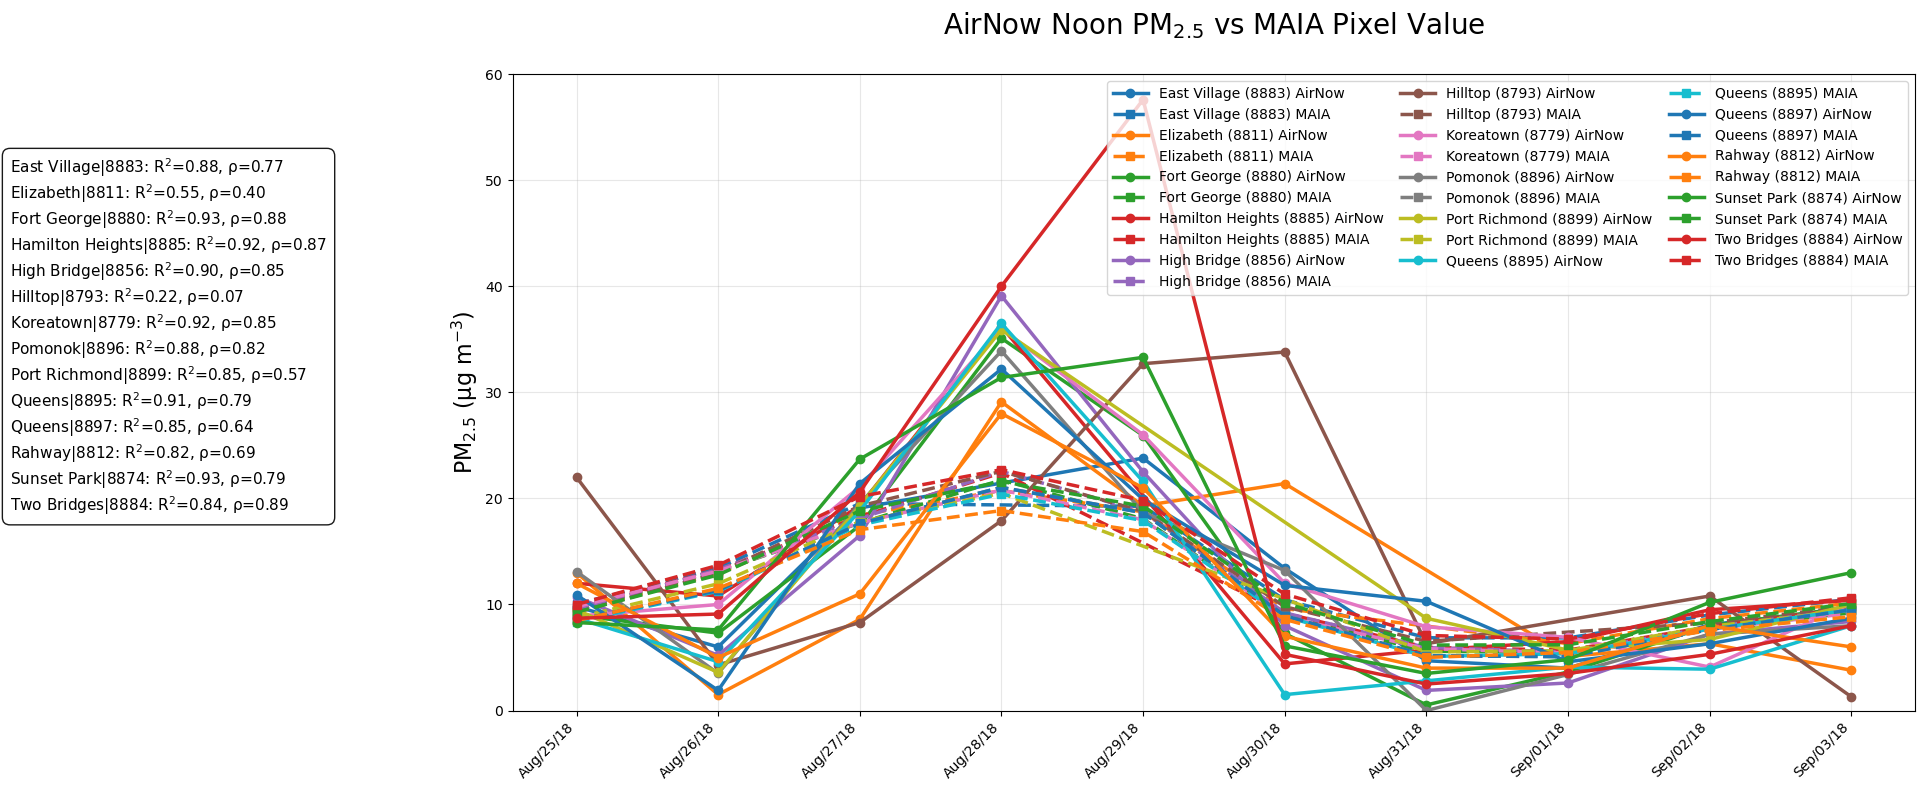

In [12]:
df = x_daily.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["STATION", "date"])
stations = (df[["STATION", "CITY"]].drop_duplicates().sort_values(["CITY", "STATION"]))
colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(16, 8))
title_lines = []

for i, (_, station_info) in enumerate(stations.iterrows()):
    station = station_info["STATION"]
    city = station_info["CITY"]
    site = (df[df["STATION"] == station].sort_values("date").dropna(subset=["pm25_noon", "maia_pm25"]))
    if len(site) < 2:continue
    rho, _ = spearmanr(site["pm25_noon"],site["maia_pm25"])
    # mae = mean_absolute_error(site["pm25_noon"],site["maia_pm25"])
    Rsquared_pearson = stats.pearsonr(site["pm25_noon"], site["maia_pm25"])[0]

    color = colors[i % len(colors)]

    ax.plot(site["date"],site["pm25_noon"],color=color,marker="o",linewidth=2.5,label=f"{city} ({station}) AirNow")
    ax.plot(site["date"],site["maia_pm25"],color=color,linestyle="--",marker="s",linewidth=2.5,label=f"{city} ({station}) MAIA")
    title_lines.append(f"{city}|{station}: R$^{2}$={Rsquared_pearson:.2f}, ρ={rho:.2f}")

ax.set_ylim(0, 60)
ax.set_ylabel("PM$_{2.5}$ (µg m$^{-3}$)", fontsize=16)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%d/%y")); 
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(alpha=0.3)
if len(stations) > 3:
    ax.set_title("AirNow Noon PM$_{2.5}$ vs MAIA Pixel Value",fontsize=20,y=1.05)
    fig.subplots_adjust(left=0.5)
    fig.text(
        -0.2,               # x position
        0.80,               # y position
        "\n".join(title_lines),
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            alpha=0.9,
            boxstyle="round,pad=0.5"
        )
    )

else:
    ax.set_title("AirNow Noon PM$_{2.5}$ vs MAIA Pixel Value\n"
        + "   |   ".join(title_lines),fontsize=20, y=1.05)
if  5< len(stations) <= 7:
    ax.legend(loc="upper right",ncol=2,fontsize=10,columnspacing=1.2,handlelength=2.5)
if  8 < len(stations):
    ax.legend(loc="upper right",ncol=3,fontsize=10,columnspacing=1.2,handlelength=2.5)
else:
    ax.legend(loc="upper right",fontsize=10)
plt.tight_layout()
plt.show()

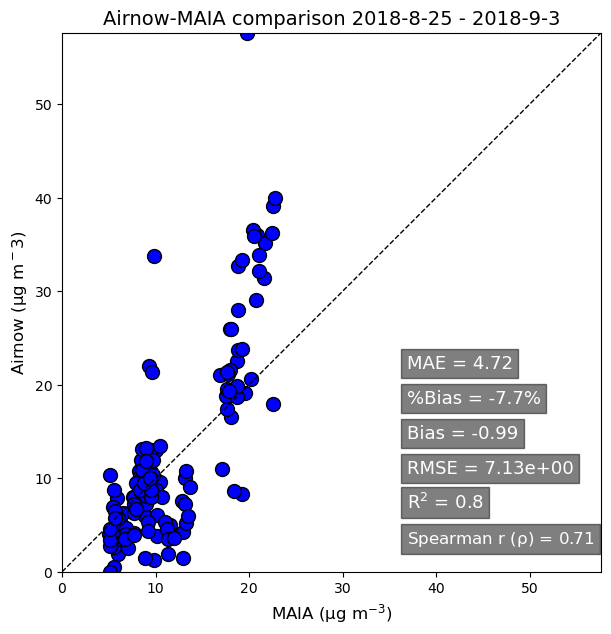

In [13]:
def airnow_v_maia(airnow, maia, date_start, date_end, fig_name=''):
    Rsquared = stats.spearmanr(airnow, maia)[0]
    pvalue = stats.spearmanr(airnow, maia)[1]
    Rsquared_pearson = stats.pearsonr(airnow, maia)[0]
    pvalue_pearson = stats.pearsonr(airnow, maia)[1]
    mae = metrics.mean_absolute_error(airnow, maia)
    bias = np.mean(maia - airnow)
    percent_bias = (100 * np.sum(maia - airnow)/ np.sum(airnow))

    #plot
    plt.rcParams.update({'mathtext.default': 'regular'})
    rmse = np.sqrt(metrics.mean_squared_error(maia, airnow))
    
    fig, ax = plt.subplots(figsize=(7, 7))
    lower_bound=0
    ax.scatter(maia, airnow, color='blue', edgecolors=(0, 0, 0), s=100)
    
    dt_start = datetime.strptime(date_start, "%Y-%m-%d %H:%M:%S")
    dt_end = datetime.strptime(date_end, "%Y-%m-%d %H:%M:%S")
    year_ini, year_fin = dt_start.year, dt_end.year
    month_ini, month_fin = dt_start.month, dt_end.month
    day_ini, day_fin = dt_start.day, dt_end.day
    upper = max(df["pm25_noon"].max(), df["maia_pm25"].max())
    ax.plot([0, upper], [0, upper], "k--", lw=1)
    ax.set_xlim(0, upper)
    ax.set_ylim(0, upper)
    ax.set_ylabel(rf'Airnow (µg m$^{-3}$)', size=12)
    ax.set_xlabel('MAIA (µg m$^{-3}$)', size=12)
    ax.set_title(f'Airnow-MAIA comparison {year_ini}-{month_ini}-{day_ini} - {year_fin}-{month_fin}-{day_fin}', fontsize=14)
    ax.tick_params(labelsize=10)
    
    bbox_props = dict(facecolor="black", alpha=0.5)
    fig.text(0.62, 0.15, r'Spearman r ($\rho$) = ' + str(round(Rsquared, 2)), fontsize=12,bbox=bbox_props, color='white')
    fig.text(0.62, 0.20, 'R$^2$ = ' + str(round(Rsquared_pearson, 2)), fontsize=13,bbox=bbox_props, color='white')
    fig.text(0.62, 0.25, f'RMSE = {rmse:.2e}', fontsize=13,bbox=bbox_props, color='white')
    plt.gca().set_aspect('equal', adjustable='box')
    fig.text(0.62,0.30,f'Bias = {bias:.2f}',fontsize=13,bbox=bbox_props,color='white')
    fig.text(0.62, 0.35, f'%Bias = {percent_bias:.1f}%', fontsize=13, bbox=bbox_props, color='white' )
    fig.text( 0.62, 0.40, f'MAE = {mae:.2f}', fontsize=13, bbox=bbox_props, color='white' )  
    plt.show()

airnow_v_maia(df['pm25_noon'], df['maia_pm25'], date_start, date_end)

In [15]:
# #bias comparison
# results = []
# for station, site in x_daily.groupby("STATION"):
#     site = site.dropna( subset=["pm25_noon", "maia_pm25"] )
#     if len(site) < 2: continue
#     bias = np.mean(site["maia_pm25"]- site["pm25_noon"])
#     mae = mean_absolute_error( site["pm25_noon"], site["maia_pm25"])
#     rmse = np.sqrt(mean_squared_error(site["pm25_noon"],site["maia_pm25"]))
#     results.append({"CITY": site["CITY"].iloc[0], "STATION": station,"Bias": bias,"MAE": mae,"RMSE": rmse,})

# metrics_df = pd.DataFrame(results)
# print(metrics_df)
# n = len(metrics_df)
# if n <= 3: ncols = n
# elif n <= 6:  ncols = 3
# else: ncols = 4
# nrows = math.ceil(n / ncols)

# fig, axes = plt.subplots(nrows,ncols,figsize=(4 * ncols,4 * nrows),sharey=True)
# axes = np.atleast_1d(axes).ravel()
# for ax, (_, row) in zip(axes, metrics_df.iterrows()):
#     vals = [row["Bias"], row["MAE"], row["RMSE"]]
#     bars = ax.bar(["Bias", "MAE", "RMSE"],vals)
#     for b in bars:
#         ax.text(
#             b.get_x() + b.get_width()/2,
#             b.get_height(),
#             f"{b.get_height():.2f}",
#             ha="center",
#             va="bottom",
#             fontsize=10 )

#     ax.set_title(
#         f"{row['CITY']} ({row['STATION']})\n"
#         f"n={len(x_daily[x_daily['STATION']==row['STATION']])}"
#     )

# for ax in axes[len(metrics_df):]: ax.set_visible(False)
# plt.suptitle("MAIA-AirNow Validation Statistics", fontsize=18, y=1)
# plt.tight_layout()
# plt.show()

In [22]:
# #exploratory analysis

# dff = pd.read_csv('AIRNOW_pm25_20180101_20181231.csv', header =0)
# dff["Timestamp"] = pd.to_datetime(dff["Timestamp"])
# dff["date"] = dff["Timestamp"].dt.date
# dff["hour"] = dff["Timestamp"].dt.hour

# # Keep only noon observations
# dff_noon = dff[dff["hour"] == 12].copy()# 
# xx = (dff_noon.groupby(["STATION", "LATITUDE", "LONGITUDE", "date"],as_index=False).agg(pm25_noon=("pm25", "mean")))

# print(xx[(xx['pm25_noon'] > 25)])

## Monthly image comparison

The following creates directories and downloads MAIA L4 images from Earthdata using the harmony tool for June, July, August 2018 during peak AirNow measurements. Three separate directories are downloaded as to not overwhelm the harmony system.

### Harmony and pyrsig reset up


In [4]:
june_dir = Path("./june_images_2018")
june_dir.mkdir(exist_ok=True)

single_var_harmony_download("C2574931653-LARC_ASDC", "MAIA_L4_GFPM", "VSIM001", 2018, 6, 1, 2018, 6, 30, june_dir, variable_select=False)

In [5]:
july_dir = Path("./july_images_2018")
july_dir.mkdir(exist_ok=True)

single_var_harmony_download("C2574931653-LARC_ASDC", "MAIA_L4_GFPM", "VSIM001", 2018, 7, 1, 2018, 7, 31, july_dir, variable_select=False)

In [6]:
aug_dir = Path("./aug_images_2018")
aug_dir.mkdir(exist_ok=True)

single_var_harmony_download("C2574931653-LARC_ASDC", "MAIA_L4_GFPM", "VSIM001", 2018, 8, 1, 2018, 8, 31, aug_dir, variable_select=False)

In [7]:
#timeframe of interest for pyrsig
print('enter period of interest, start and end dates, in the form YYYYMMDD')
datestamp_ini = input('enter start date of interest ')
datestamp_fin = input('enter end date of interest ')

start_date = int(datestamp_ini)
end_date = int(datestamp_fin)

yyyy_ini = start_date//10000
mm_ini = (start_date//100 - yyyy_ini*100)
dd_ini = (start_date - yyyy_ini*10000 - mm_ini*100)

yyyy_fin = end_date//10000
mm_fin = (end_date//100 - yyyy_fin*100)
dd_fin = (end_date - yyyy_fin*10000 - mm_fin*100)
print(yyyy_ini, mm_ini, dd_ini, yyyy_fin, mm_fin, dd_fin)

date_start = str('%4.4i-%2.2i-%2.2i 00:00:00' %(yyyy_ini, mm_ini, dd_ini))
date_end = str('%4.4i-%2.2i-%2.2i 23:59:59' %(yyyy_fin, mm_fin, dd_fin))

enter period of interest, start and end dates, in the form YYYYMMDD


enter start date of interest  20180601
enter end date of interest  20180831


2018 6 1 2018 8 31


In [10]:
x = take_airnow_inputs(date_start, date_end, start_date, end_date, polygon_corners, save = True)

https://ofmpub.epa.gov/rsig/rsigserver?SERVICE=wcs&VERSION=1.0.0&REQUEST=GetCoverage&FORMAT=ascii&TIME=2018-06-01T00:00:00Z/2018-08-31T23:59:59Z&BBOX=-74.3022812141979,40.488222206252246,-73.7097187858021,40.93737779374776&COVERAGE=airnow.pm25&COMPRESS=1
Using cached: ./airnow.pm25_2018-06-01T000000Z_2018-08-31T235959Z.csv.gz


In [11]:
x_daily = df_setup_noon(x)

8779.0 -> Koreatown
8793.0 -> Hilltop
8811.0 -> Elizabeth
8856.0 -> High Bridge
8874.0 -> Sunset Park
8875.0 -> Brooklyn
8880.0 -> Fort George
8883.0 -> East Village
8884.0 -> Two Bridges
8885.0 -> Hamilton Heights
8895.0 -> Queens
8896.0 -> Pomonok
8897.0 -> Queens
8899.0 -> Port Richmond
8812.0 -> Rahway


/tmp/ipykernel_2326/3127938063.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


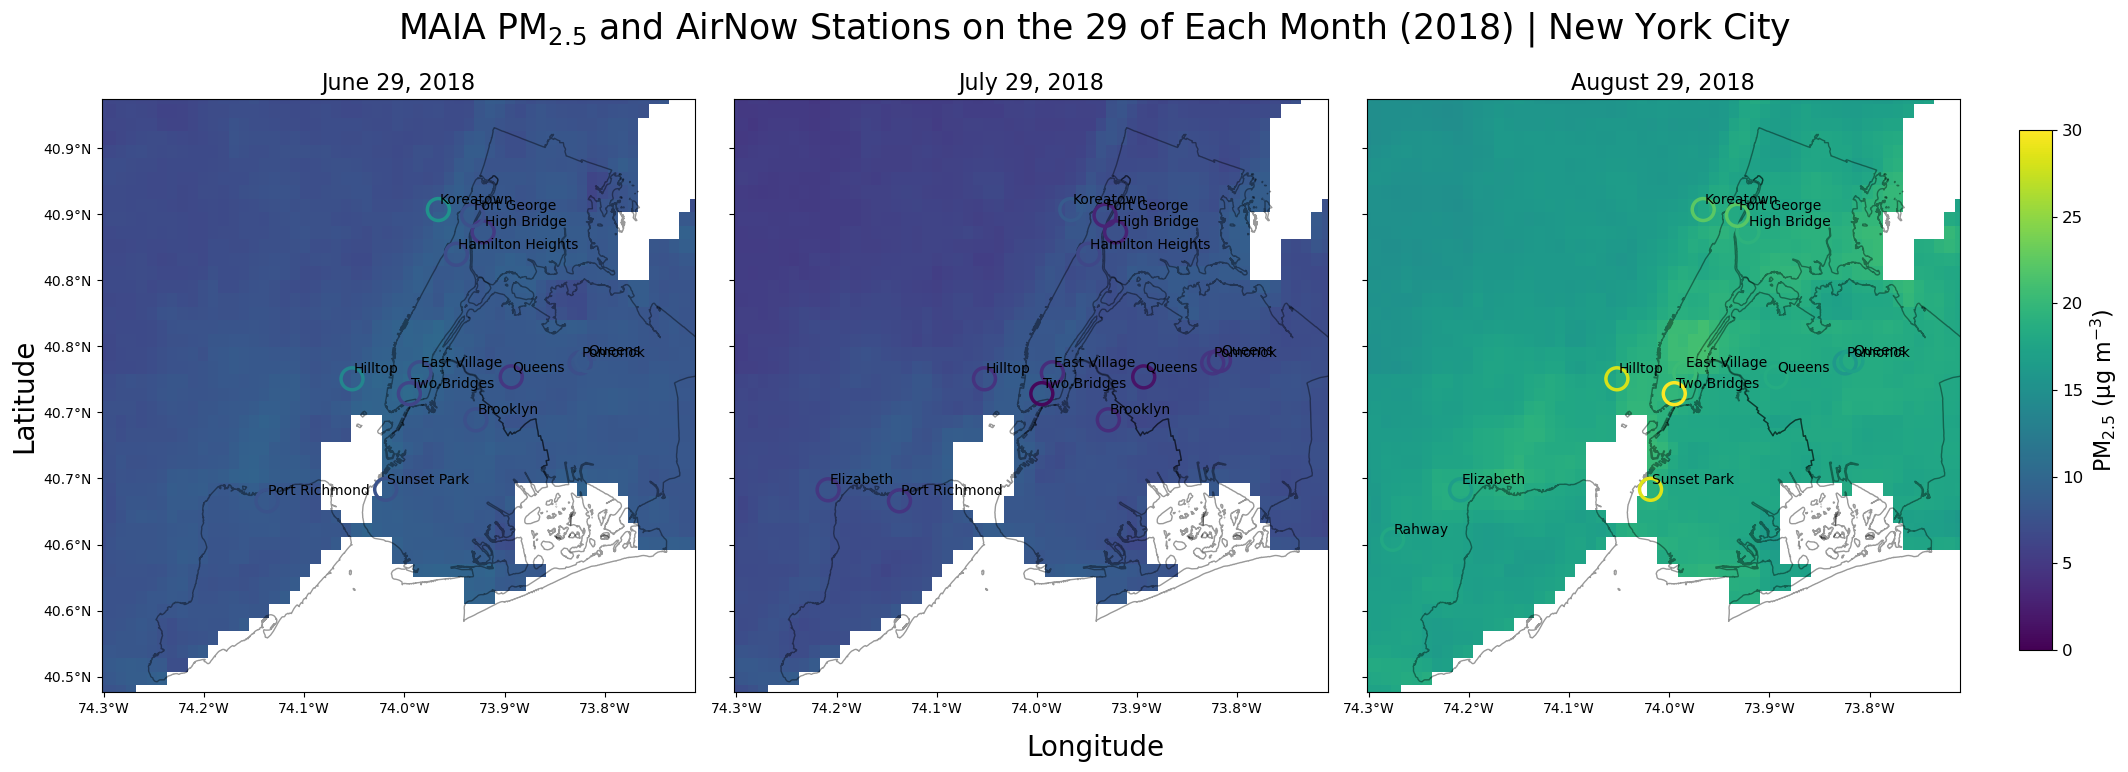

In [12]:
dirs = ["june_images_2018","july_images_2018","aug_images_2018"]
titles = ["June 29, 2018","July 29, 2018","August 29, 2018"]
selected_files = []
for d in dirs:
    match_file = None
    for fname in sorted(os.listdir(d)):
        if not fname.endswith(".tif"):
            continue
        match = re.search(r"(\d{8})T\d{6}Z",fname)

        if match is None:
            continue
        dt = match.group(1)
        day = int(dt[6:8])

        if day == 29:
            match_file = os.path.join(d,fname)
            break

    if match_file is None:
        raise FileNotFoundError(f"No day-29 file found in {d}")
    selected_files.append(match_file)


#make lat/lon
images = []
extents = []
for tif in selected_files:
    with rasterio.open(tif) as src:
        img = src.read(1).astype(np.float32)
        if src.nodata is not None:
            img[np.isclose(img, src.nodata)] = np.nan

        img[img > 1e20] = np.nan
        dst_transform, dst_width, dst_height = (
            calculate_default_transform( src.crs,"EPSG:4326", src.width, src.height, *src.bounds))

        dst = np.full( (dst_height, dst_width), np.nan, dtype=np.float32)
        reproject( source=img, destination=dst, src_transform=src.transform, src_crs=src.crs, dst_transform=dst_transform, dst_crs="EPSG:4326", resampling=Resampling.bilinear, dst_nodata=np.nan)
        valid = np.isfinite(dst)
        rows, cols = np.where(valid)
        rmin = rows.min()
        rmax = rows.max()
        cmin = cols.min()
        cmax = cols.max()

        dst = dst[rmin:rmax + 1,cmin:cmax + 1]
        pixel_width = dst_transform.a
        pixel_height = dst_transform.e
        left = (dst_transform.c+ cmin * pixel_width)
        right = ( dst_transform.c + (cmax + 1) * pixel_width )
        top = ( dst_transform.f + rmin * pixel_height)
        bottom = (dst_transform.f+ (cmax*0 + rmax + 1)* pixel_height)
        images.append(dst)
        extents.append([left, right, bottom, top])

poly_lons = [p[1] for p in polygon_corners]
poly_lats = [p[0] for p in polygon_corners]
xmin = min(poly_lons)
xmax = max(poly_lons)
ymin = min(poly_lats)
ymax = max(poly_lats)

fig, axes = plt.subplots(1,3,figsize=(22, 8), sharex=True)
cmap = plt.cm.viridis.copy()
cmap.set_bad(alpha=0)

plot_dates = [pd.Timestamp("2018-06-29").date(),pd.Timestamp("2018-07-29").date(),pd.Timestamp("2018-08-29").date()]

for ax, img, extent, title, plot_date in zip(axes,images,extents,titles,plot_dates):
    masked = np.ma.masked_invalid(img)
    im = ax.imshow(masked,extent=extent,cmap=cmap,vmin=0,vmax=30,origin="upper")
    station_day = (x_daily[x_daily["date"] == plot_date].copy())
    if shp_dir.is_dir():
        roads.plot(ax=ax,edgecolor="black", facecolor="none", linewidth=1, alpha=0.4, zorder=5)
    if len(station_day) > 0:
        for _, row in station_day.iterrows():
            color = cmap(np.clip(row["pm25_noon"] / 35.0, 0, 1))

            ax.scatter(row["LONGITUDE"],row["LATITUDE"],facecolors="none",edgecolors=[color], s=250, linewidths=2.5,zorder=10)
            ax.annotate(row["CITY"],(row["LONGITUDE"],row["LATITUDE"]),xytext=(1, 4),textcoords="offset points",fontsize=10,zorder=11)
            
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.xaxis.set_major_formatter(FuncFormatter( lambda x, pos: f"{abs(x):.1f}°{'W' if x < 0 else 'E'}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos:f"{abs(y):.1f}°{'S' if y < 0 else 'N'}"))
    ax.set_title(title, fontsize=16)
    
for ax in axes[1:]:
    ax.tick_params(axis="y", left=True, labelleft=False)

ax.set_xlabel("",)
axes[0].set_ylabel("Latitude",fontsize=20)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.65])
cbar = plt.colorbar(im, cax=cbar_ax)
cbar.set_label("PM$_{2.5}$ (µg m$^{-3}$)",fontsize=16)
cbar.ax.tick_params(labelsize=12)
plt.suptitle("MAIA PM$_{2.5}$ and AirNow Stations on the 29 of Each Month (2018) | New York City",y=0.95,fontsize=25)
fig.supxlabel("Longitude",fontsize=20)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
                   
plt.show()